# HW 2: Wrangling

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?
3. Dummy variable: For the pretrial data covered in the lecture, clean the `WhetherDefendantWasReleasedPretrial` variable as well as you can, and, in particular, replace missing values with `np.nan`.
4. Missing values, not at random: For the pretrial data covered in the lecture, clean the `ImposedSentenceAllChargeInContactEvent` variable as well as you can, and explain the choices you make. (Hint: Look at the `SentenceTypeAllChargesAtConvictionInContactEvent` variable.)

**Answers**:

1. Cleaning the numeric variable (Shown below).

    The steps I used to clean the data set was to first create a duplicate copy of the airbnb csv file, just in case I needed to go back to the original copy. Then, I created a dataframe with the file to clean it. I used the .describe() function to get an understanding of what the data looked like. Then, I removed any characters ($ or ,) and coerced the values to numeric using the Pandas method, gathering the number of missing values (0). Without cleaning it, numbers of 999 would have been incorrectly coerced into missing values.

Before coercion: 
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion: 
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total Missings: 
 0 



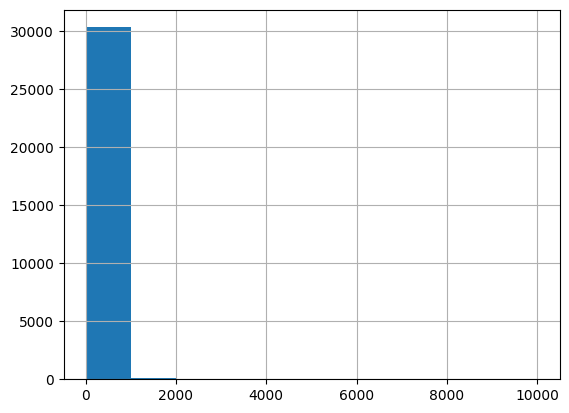

In [93]:
import pandas as pd  # Import the pandas package into your workspace

df = pd.read_csv('./data/airbnb_hw.csv',low_memory=False)
# print(df.shape, '\n') # List the dimensions of df
# print(df.dtypes, '\n') # The types of the variables; `object` is a bad sign
# print(df.columns, '\n') # Column names

var = 'Price'

print('Before coercion: \n', df[var].describe(),'\n') 
# df[var].hist(bins=50)

# Coercion 

df[var] = df[var].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

df[var] = pd.to_numeric(df[var], errors='coerce') # Coerce the variable to numeric
df['Price_nan'] = df[var].isnull() # Equals 1 if missing, 0 if non-null

# After coercion:
print('After coercion: \n', df[var].describe(),'\n') # Describe the numeric variable
df[var].hist() # Histogram of the variable values
print('Total Missings: \n', sum(df['Price_nan']),'\n') # How many missing values are there?

df.to_csv('./data/airbnb_hw_cleaned.csv')

2. Cleaning the Categorical Data (Shown Below):

    The steps I used to clean the data set was to first create a duplicate copy of the mn_police_use_of_force csv file, just in case I needed to go back to the original copy. Then, I created a dataframe with the file to clean it. I used the .unique() function to get an understanding of what the categories looked like. Then, I replaced all the missing data (' ') with np.nan to clean it, then created a dummy variable with the missing values. Afterwards, I calculated the proportion of missing values in subject_injury, to see if it was a concern or not. From the results, it seems like the missing values are a big concern, given that 76% of the data contained missing values. After crosstabulating the data, it shows that missing values are more common in less frequent force types. On the other hand common force types seem to have more complete data. This could mean that the missing data isn't random and could potentially be misinterpreted if not handled with.

[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Axes(0.125,0.11;0.775x0.77) 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Proportion of missing values in subject_injury: 0.76 

force_type              Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_missing                                                    
0                           2          2379                172        2   
1                           2          7051               1421        0   

force_type              Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury_missing                                                      
0                                      77                 74            0   
1                                      27                 74           87   

force_type              Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury_missing                                                   

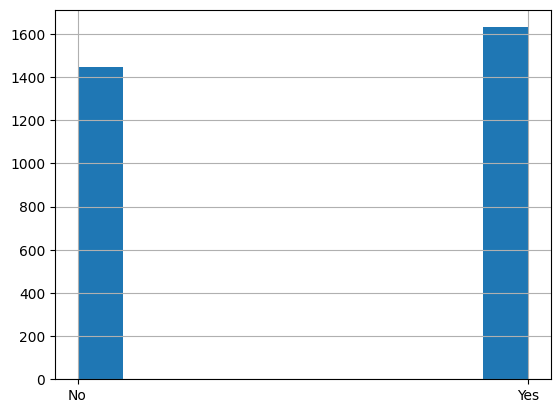

In [94]:
import numpy as np
import pandas as pd 

df = pd.read_csv('./data/mn_police_use_of_force.csv',low_memory=False)

var = 'subject_injury'

print(df[var].unique(),'\n') 
print(df[var].value_counts(), '\n') 
print(df[var].hist(), '\n') 

df[var] = df[var].replace(' ',np.nan) 
df['subject_injury_missing'] = df['subject_injury'].isna().astype(int)
print(df[var].value_counts(), '\n')

missing_prop = df[var].isna().mean()
print(f"Proportion of missing values in {var}: {missing_prop:.2f}", '\n')

#cross tabulating data

print(pd.crosstab(df['subject_injury_missing'], df['force_type']))

df.to_csv('./data/mn_police_use_of_force_cleaned.csv')

3. Cleaning the Dummy Data (Shown Below):

    The steps I used to clean the data set was very similar to the categorical data process. I replaced all the missing data (9) with np.nan, and created another dummy variable for the missing values.

[9 0 1] 

WhetherDefendantWasReleasedPretrial
1    19154
0     3801
9       31
Name: count, dtype: int64 

Axes(0.125,0.11;0.775x0.77) 

WhetherDefendantWasReleasedPretrial
1.0    19154
0.0     3801
Name: count, dtype: int64 

released_pretrial_missing
0    22955
1       31
Name: count, dtype: int64


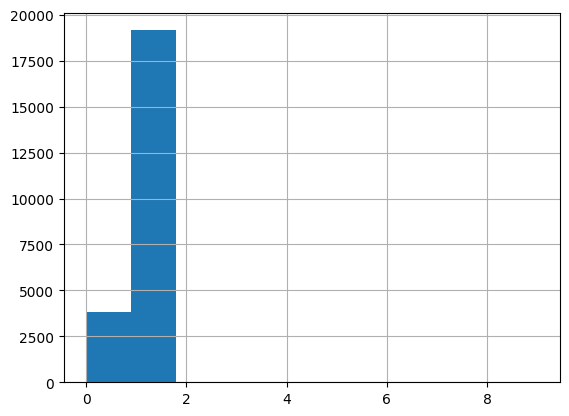

In [95]:
import numpy as np
import pandas as pd 

url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
df = pd.read_csv(url,low_memory=False) # Pandas downloads and loads the .csv file for you

# df = pd.read_parquet('./data/justice_data.parquet') # If necessary...

var = 'WhetherDefendantWasReleasedPretrial'

print(df[var].unique(),'\n') 
print(df[var].value_counts(), '\n') 
print(df[var].hist(), '\n') 

df[var] = df[var].replace(9,np.nan) 
df['released_pretrial_missing'] = df[var].isna().astype(int)
print(df[var].value_counts(), '\n')
print(df['released_pretrial_missing'].value_counts())

df.to_csv('./data/justice_data_cleaned.csv')

4. Cleaning the Missing values (Shown Below):

    The steps I used to clean the ImposedSentenceAllChargeInContactEvent variable were that I inspected the raw values using .unique() and .value_counts() to understand the data. Then, I removed extra characters ($ and ,) and coerced the values to numeric. This converted valid numbers to floats and turned invalid or blank entries into NaN. Then, I created a dummy variable to flag which rows were missing. After cleaning, I calculated that there are 9053 missing values. Looking at the SentenceTypeAllChargesAtConvictionInContactEvent variable shows that missing values are not at random, meaning that certain sentence types (like “No Sentence”) always correspond to missing imposed sentences.

[' ' '60' '12' '.985626283367556' '36' '6' '24' '5.91375770020534' '120'
 '72' '11.9917864476386' '0' '2.95687885010267' '84' '108' '300' '240'
 '180' '4' '96' '2' '54' '.328542094455852' '44' '5' '115' '132' '48'
 '258' '34' '76' '.164271047227926' '.131416837782341' '111' '9' '3'
 '1.97125256673511' '36.9856262833676' '.0657084188911704'
 '35.4928131416838' '106.492813141684' '8' '35' '18.3141683778234' '480'
 '32' '93' '234' '732' '1.16427104722793' '4.6570841889117' '21' '7'
 '4.49281314168378' '18' '600' '43.1642710472279' '179' '52' '30' '20'
 '192' '702' '14' '55' '53' '11.9055441478439' '114' '35.0061601642711'
 '68' '.657084188911704' '46.6242299794661' '102' '65' '200' '57'
 '24.3285420944559' '12.1642710472279' '117' '81.4928131416838'
 '22.4928131416838' '1980' '3.6570841889117' '56' '10' '2.79260780287474'
 '1' '47' '22' '1500' '40' '284' '11' '118' '42' '162' '156'
 '47.2956878850103' '105' '51' '246' '29' '75' '324' '360'
 '34.4804928131417' '120.328542094456' '59.926078

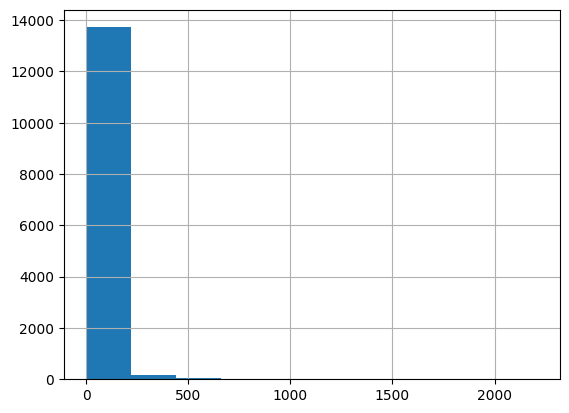

In [96]:
import numpy as np
import pandas as pd 

url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
df = pd.read_csv(url,low_memory=False) # Pandas downloads and loads the .csv file for you

# df = pd.read_parquet('./data/justice_data.parquet') # If necessary...

var = 'ImposedSentenceAllChargeInContactEvent'

print(df[var].unique(),'\n') 
# print(df['SentenceTypeAllChargesAtConvictionInContactEvent'].unique(),'\n') 
print(df[var].value_counts(), '\n') 

df[var] = df[var].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

df[var] = pd.to_numeric(df[var], errors='coerce') # Coerce the variable to numeric
df['charge_nan'] = df[var].isnull() # Equals 1 if missing, 0 if non-null

# After coercion:
print('After coercion: \n', df[var].describe(),'\n') # Describe the numeric variable
df[var].hist() # Histogram of the variable values
print('Total Missings: \n', sum(df['charge_nan']),'\n') 

df.to_csv('./data/justice_data_pt_2_cleaned.csv')

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Are sharks more likely to launch unprovoked attacks on men or women? Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Is it more or less likely to be fatal when the victim is male or female? How do you feel about sharks?
9. What proportion of attacks appear to be by white sharks? (Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

**Answers:**

    1. Used openpyxl package to read file as an excel file
    2. Dropped columns.
    3. Cleaned the Year variable. Within the values, I see a range of the years 1500-2026, with some outliers like (1000, 0, 5, 77, and nan). Looking at the filtered rows and plotted line graph, the attacks seemed to increase within the years, with recent years dropping.
    4. Cleaned the Age variable and made a histogram.
    5. There seems to be a 78.71% proportion of male victims.
    6. Cleaned the Type variable. There is a 74.49%  proportion of attacks that are unprovoked.
    7. Cleaned the Fatal Y/N variable
    8. According to the data, sharks are more likely to launch unprovoked attacks on women than men (where men are attacked unprovoked 88.18% of the time, while women are attacked unprovoked 95.66% of the time.) Men however have a higher total number of unprovoked attacks because there are more men that are attacked than women overall. Additionally, the attacks are much more likely to be fatal when unprovoked, rather than provoked, with unprovoked attacks being 16.48% fatal, and provoked attacks being 2.51% fatal. Finally, it is more lkely to be fatal when it is a male victim, with it being 15.23% fatal for men, and 13.49% fatal for women. Overall, I think that sharks are honestly misunderstood and misrepresented creatures, often villainized by movies like 'Jaws'. These statistics show that the fatality rate of sharks are quite low despite their depiction in media to be "bloodthirsty killers". It only shows that even though shark attacks are a real occurence, they are really only cautionary tale.
    9. White sharks as a species seems to make up 6.96% of shark attacks.

[2026. 2016. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914. 1913. 1912. 1911. 1910. 1909.
 1908. 1907. 1906. 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1897.
 1896. 1895. 1894. 1893. 1892. 1891. 1890. 1889. 1888. 1887. 1886. 1885.
 1884. 1883. 1882. 1881. 1880. 1879. 1878. 1877. 1876. 1875. 1874. 1873.
 1872. 1871. 1870. 1869. 1868. 1867. 1866. 1865. 18

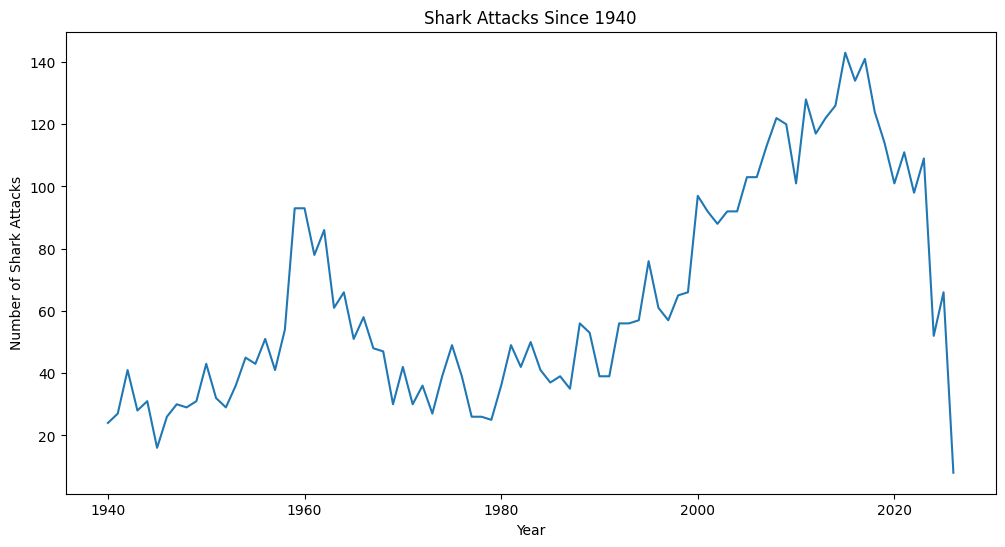

['39' '11' '27' '12' '?' '56' '55' '24' '26' '25' '61' '40' '13' '14'
 '50+' '54' '48' '57' '8' '63' '9' '19' '7' '85' '69' '18' '66' '21' '37'
 '16' '20' '42' '45' '30' '30+' '40+' '29' 35 58 29 24 20 55 17 12 37 36
 23 40 28 69 48 '60+' 57 45 61 27 38 16 68 33 30 15 41 14 43 26
 'Middle age' 18 21 49 25 46 19 65 64 nan '46' '32' '10' '64' '62' '22'
 '15' '52' '44' '47' '59' '50' '34' '38' '30s' '20/30' '35' '65' '20s'
 '77' '60' '49' '!2' '73' '50s' '58' '67' '17' '6' '41' '53' '68' '43'
 '51' '31' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M' 9 31
 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' "20's" 67 74 '9 & 60' 'a minor' 6 3 82 '40?'
 66 72 '23' '36' '71' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5'
 '86' '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'
 '16 to

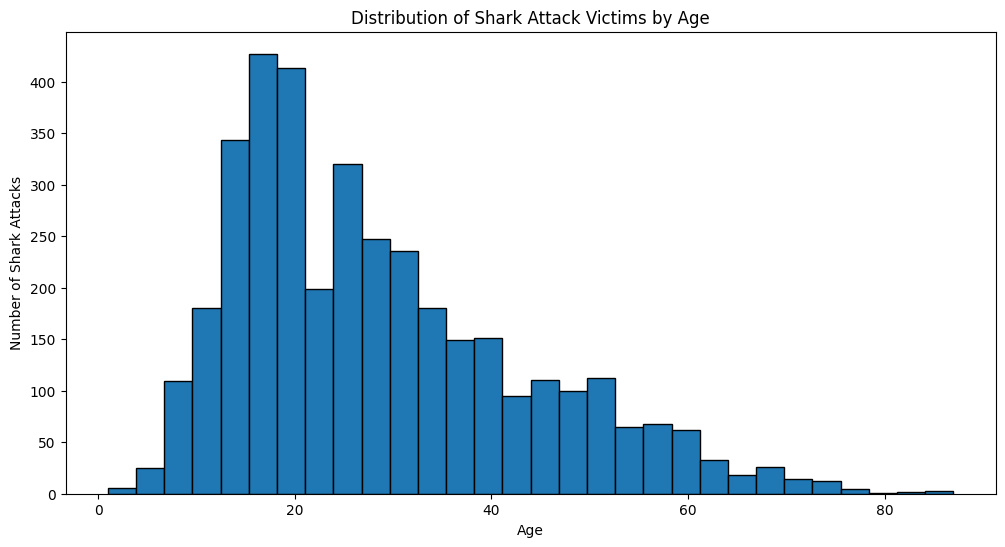

Proportion of male victims: 78.71%
['Unprovoked' 'Provoked' 'Questionable' 'unprovoked' ' Provoked'
 'Watercraft' 'Sea Disaster' nan '?' 'Unconfirmed' 'Unverified' 'Invalid'
 'Under investigation' 'Boat'] 

Type
Unprovoked             4121
Provoked                521
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             26
Boat                      7
 Provoked                 2
unprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64 

Type_clean
Unprovoked    4122
Unknown        889
Provoked       523
Name: count, dtype: int64 

Proportion of unprovoked attacks: 74.49%
['N' 'Y' 'F' 'M' nan 'n' 'Nq' 'UNKNOWN' 2017 'Y x 2' ' N'] 

Fatal Y/N
N          4235
Y           829
UNKNOWN      45
 N            7
F             5
M             3
Nq            1
n             1
2017          1
Y x 2         1
Name: count, dtype: int64 



In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

df = pd.read_excel('./data/GSAF5.xlsx') 

df = df.dropna(axis=1, how='all')

# Year
var = 'Year'
print(df[var].unique(),'\n')
df[var] = pd.to_numeric(df[var], errors='coerce') 
df['year_nan'] = df[var].isnull() # Equals 1 if missing, 0 if non-null
print('After coercion: \n', df[var].unique(),'\n')
print('Total Missings: \n', sum(df['year_nan']),'\n') 

# filtering and plotting data for attacks past 1940
df = df[df['Year'] >= 1940]
attacks_per_year = df['Year'].value_counts().sort_index()
print(attacks_per_year)
attacks_per_year.sort_index().plot(kind='line', figsize=(12,6))
plt.xlabel('Year')
plt.ylabel('Number of Shark Attacks')
plt.title('Shark Attacks Since 1940')
plt.show()

# Age
var = 'Age'
print(df[var].unique(),'\n')
df[var] = df[var].astype(str).str.strip().str.lower()
df[var] = df[var].str.extract(r'(\d+)')  # Extract numeric part if age is in a string format like '25 years'
df[var] = pd.to_numeric(df[var], errors='coerce') 
df['age_nan'] = df[var].isnull() # Equals 1 if missing, 0 if non-null
print('After coercion: \n', df[var].unique(),'\n')
print('Total Missings: \n', sum(df['age_nan']),'\n')

# creating a histogram
plt.figure(figsize=(12,6))
plt.hist(df['Age'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of Shark Attacks')
plt.title('Distribution of Shark Attack Victims by Age')
plt.show()

# Sex
var = 'Sex'
df[var] = df[var].astype(str).str.strip().str.lower()
sex_counts = df[var].value_counts(dropna=True)
male_proportion = sex_counts.get('m', 0) / sex_counts.sum()
print(f"Proportion of male victims: {male_proportion:.2%}")

# Type
var = 'Type'
print(df[var].unique(),'\n') 
print(df[var].value_counts(), '\n') 
df[var] = df[var].astype(str).str.strip().str.capitalize()
df[var] = df[var].replace('?',np.nan) 
df['Type_missing'] = df[var].isna().astype(int)
df['Type_clean'] = df[var].where(df[var].isin(['Unprovoked', 'Provoked']), 'Unknown')
print(df['Type_clean'].value_counts(), '\n')
unprovoked_prop = df['Type_clean'].value_counts(normalize=True).get('Unprovoked', 0)
print(f"Proportion of unprovoked attacks: {unprovoked_prop:.2%}")

# Fatal Y/N
var = 'Fatal Y/N'
print(df[var].unique(),'\n')
print(df[var].value_counts(), '\n') 
df[var] = df[var].astype(str).str.strip().str.upper()
df['Fatal_clean'] = df[var].replace({
    'Y X 2': 'Y',  
    'N ': 'N',     
    'UNKNOWN': 'UNKNOWN'
})
df['Fatal_clean'] = df['Fatal_clean'].where(df['Fatal_clean'].isin(['Y', 'N']), 'Unknown')
print(df['Fatal_clean'].value_counts(), '\n')

# crosstab data cleaning
df_clean = df.copy()
df_clean = df_clean[df_clean['Sex'].isin(['m','f'])]
df_clean = df_clean[df_clean['Type_clean'].isin(['Unprovoked','Provoked'])]

# crosstab: sex vs type
sex_type_ct = pd.crosstab(df_clean['Sex'], df_clean['Type_clean'])
sex_type_pct = sex_type_ct.div(sex_type_ct.sum(axis=1), axis=0) * 100
print("Unprovoked vs Provoked by Sex (Counts):\n", sex_type_ct, "\n")
print("Unprovoked vs Provoked by Sex (Percentages):\n", sex_type_pct.round(2), "\n")

# crosstab: fatal vs type
fatal_type_ct = pd.crosstab(df_clean['Type_clean'], df_clean['Fatal_clean'])
fatal_type_pct = fatal_type_ct.div(fatal_type_ct.sum(axis=1), axis=0) * 100
print("Fatal vs Non-Fatal by Attack Type (Counts):\n", fatal_type_ct, "\n")
print("Fatal vs Non-Fatal by Attack Type (Percentages):\n", fatal_type_pct.round(2), "\n")

# crosstab: fatal vs sex
fatal_sex_ct = pd.crosstab(df_clean['Sex'], df_clean['Fatal_clean'])
fatal_sex_pct = fatal_sex_ct.div(fatal_sex_ct.sum(axis=1), axis=0) * 100
print("Fatal vs Non-Fatal by Sex (Counts):\n", fatal_sex_ct, "\n")
print("Fatal vs Non-Fatal by Sex (Percentages):\n", fatal_sex_pct.round(2), "\n")

# Species

var = 'Species '
print(df[var].unique(),'\n')
df['Species_clean'] = df[var].astype(str).str.lower().str.strip() 
df['Species_list'] = df['Species_clean'].str.split()
df['Is_White_Shark'] = df['Species_list'].apply(lambda x: 'white' in x and 'shark' in x)
white_shark_count = df['Is_White_Shark'].sum()
total_attacks = df['Is_White_Shark'].shape[0]

white_shark_prop = white_shark_count / total_attacks
print(f"Number of white shark attacks: {white_shark_count}")
print(f"Proportion of white shark attacks: {white_shark_prop:.2%}")

df.to_csv('cleaned_shark_attacks.csv', index=False)

**Q3.** Open the "tidy_data.pdf" document in the repo, which is a paper called Tidy Data by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?
  8. Read Section 6. What is the "chicken-and-egg" problem with focusing on tidy data? What does Wickham hope happens in the future with further work on the subject of data wrangling?

**Answers**
 
1. The paper is about data tidying, a component of data cleaning that makes datasets easy and effective as possible to manipulate, model, and visualize.

2. The tidy data standard is designed to facilitate initial exploration and analysis of the data, and to simplify the development of data analysis tools that work well together.

3. The first sentence is a reference to the sentence quoted above it: "Happy families are all alike; every unhappy family is unhappy in its own way.". This means means that while tidy datasets are all similar and have similar structure (like family members are related by blood), messy datasets all have their own unique quirks need to be sorted out individually (they may not be the same type of "messy" as others). The second sentence means that the "standard" characterization of observations are variables seem apparent at first glance when sorting them into categories, but the interpretation of those variables and observations given the data is much harder to visualize. Each dataset is dependent on how you analyze the data.

4. Wickham defines values as "numbers (if quantitative) or strings (if qualitative)". Variables "contain all values that measure the same underlying attribute (like height, temperature, duration) across units. An observation "contains all values measured on the same unit (like a person, or a day, or a race) across attributes.

5. "Tidy Data" is defined as a standard way of mapping the meaning to a dataset to its structure. In tidy data, 1) Each variable forms a column, 2) Each observation forms a row, and 3) Each type of observational unit forms a table.

6. The five most common problems with messy datasets are:
    1. Column headers are values, not variable names
    2. Multiple variables are stored in one column
    3. Variables are stored in both rows and columns
    4. Multiple types of observational units are stored in the same table
    5. A single observational unit is stored in multiple tables.

The data is Table 4 is messy because it puts column headers as values, not variable names. "Melting" or "stacking" a dataset is a way of tidying the data by turning the columns into rows.

7. Table 11 is messy because there is a column for each possible day in the month, which creates a lot of empty data. Table 12 is tidy and "molten" because missing values are dropped to conserve space, and the column names are now variable names.

8. The "chicken-and-egg" problem with tidy data is this: "if tidy data is only as useful as the tools that work with it, then tidy tools will be inextricably linked to tidy data." This is essentially a loop, where independently changing data structures or data tools will not improve workflow. Wickham hopes that in the future, further work with cleaning data (parsing dates and numbers, identifying missing values, correcting character encodings, model-based data cleaning that identifies suspicious values) will make these tasks easier.